
# DVFM Gaussian-Latent Mechanistic Benchmark

This notebook analyzes the controlled synthetic benchmark and asks whether a **shared latent** improves baseline event-time prediction specifically because it captures dependent censoring.

Models:
- `no_latent`, \(d_z=0\)
- `shared`, \(d_z\in\{1,20\}\)
- `separate`, \(d_z\in\{1,20\}\)

Primary signal: Oracle IBS. Lower is better.


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR_CANDIDATES = [Path("../results/synthetic_gaussian_latent")]
RESULT_DIR = next(
    (p for p in RESULT_DIR_CANDIDATES if (p / "results_raw.csv").exists()),
    RESULT_DIR_CANDIDATES[0],
)

RAW_PATH = RESULT_DIR / "results_raw.csv"
HISTORY_DIR = RESULT_DIR / "training_history"

print("Result directory:", RESULT_DIR.resolve())
if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Missing {RAW_PATH}. Run the experiment first or update RESULT_DIR."
    )

Result directory: /home/thecml/dvfm-survival/results/synthetic_gaussian_latent


## 1. Load and validate results

In [ ]:
raw = pd.read_csv(RAW_PATH)

if "status" in raw.columns:
    failed = raw.loc[raw["status"] != "ok"].copy()
    results = raw.loc[raw["status"] == "ok"].copy()
else:
    failed = pd.DataFrame()
    results = raw.copy()

print("Rows:", len(raw))
print("Successful:", len(results))
print("Failed:", len(failed))

if len(failed):
    display(failed[[c for c in [
        "seed", "target_tau", "target_censoring",
        "architecture", "latent_dim", "error"
    ] if c in failed.columns]])

required = {
    "seed", "target_tau", "target_censoring",
    "architecture", "latent_dim", "oracle_ibs"
}
missing = required.difference(results.columns)
if missing:
    raise KeyError(f"Missing expected columns: {sorted(missing)}")

results = results.sort_values(
    ["target_tau", "target_censoring", "seed", "architecture", "latent_dim"]
).reset_index(drop=True)
display(results.head())

Rows: 150
Successful: 150
Failed: 0


,seed,target_tau,target_censoring,architecture,latent_dim,n_samples,n_features,train_size,validation_size,test_size,...,event_latent_probe_pearson,event_latent_probe_r2,event_best_single_dim_abs_pearson,censor_latent_probe_pearson,censor_latent_probe_r2,censor_best_single_dim_abs_pearson,event_posterior_total_kl,event_active_dims,censor_posterior_total_kl,censor_active_dims
0,0,0.0,0.3,no_latent,0,5000,10,3500,750,750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0.0,0.3,separate,1,5000,10,3500,750,750,...,0.052698,-0.001743,0.052698,-0.004475,-0.003028,0.004475,1.138267,1.0,0.726318,1.0
2,0,0.0,0.3,separate,20,5000,10,3500,750,750,...,-0.014882,-0.009548,0.074758,0.055350,0.000459,0.104504,0.892039,1.0,0.525455,1.0
3,0,0.0,0.3,shared,1,5000,10,3500,750,750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0.0,0.3,shared,20,5000,10,3500,750,750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
coverage = (
    results.groupby(
        ["target_tau", "target_censoring", "architecture", "latent_dim"]
    )["seed"]
    .nunique()
    .rename("n_seeds")
    .reset_index()
)
display(coverage)

,target_tau,target_censoring,architecture,latent_dim,n_seeds
0,0.00,0.3,no_latent,0,5
1,0.00,0.3,separate,1,5
2,0.00,0.3,separate,20,5
3,0.00,0.3,shared,1,5
4,0.00,0.3,shared,20,5
5,0.00,0.7,no_latent,0,5
6,0.00,0.7,separate,1,5
7,0.00,0.7,separate,20,5
8,0.00,0.7,shared,1,5
9,0.00,0.7,shared,20,5


## 2. DGP sanity checks

In [ ]:
cols = [c for c in [
    "target_tau", "conditional_tau_calibrated",
    "target_censoring", "achieved_censoring",
    "true_latent_loading", "overall_time_tau"
] if c in results.columns]

if cols:
    dgp = (
        results[cols]
        .drop_duplicates()
        .groupby(["target_tau", "target_censoring"], as_index=False)
        .mean(numeric_only=True)
    )
    display(dgp)

,target_tau,target_censoring,conditional_tau_calibrated,achieved_censoring,true_latent_loading,overall_time_tau
0,0.00,0.3,-0.004488,0.3,0.000000,-0.004452
1,0.00,0.7,-0.004488,0.7,0.000000,-0.004452
2,0.50,0.3,0.500000,0.3,2.893532,0.459929
3,0.50,0.7,0.500000,0.7,2.893532,0.459929
4,0.75,0.3,0.750000,0.3,6.996215,0.725872
5,0.75,0.7,0.750000,0.7,6.996215,0.725872


## 3. Matched shared-vs-no-latent and shared-vs-separate comparisons

In [ ]:
keys = ["seed", "target_tau", "target_censoring"]

no_latent = (
    results.loc[results["architecture"] == "no_latent", keys + ["oracle_ibs"]]
    .rename(columns={"oracle_ibs": "no_latent_oracle_ibs"})
)

shared = results.loc[results["architecture"] == "shared"].copy()
shared = shared.merge(no_latent, on=keys, how="inner")
shared["delta_ibs_vs_no_latent"] = (
    shared["oracle_ibs"] - shared["no_latent_oracle_ibs"]
)

separate = results.loc[results["architecture"] == "separate"].copy()
shared = shared.merge(
    separate[keys + ["latent_dim", "oracle_ibs"]].rename(
        columns={"oracle_ibs": "separate_oracle_ibs"}
    ),
    on=keys + ["latent_dim"],
    how="left",
)
shared["delta_ibs_shared_vs_separate"] = (
    shared["oracle_ibs"] - shared["separate_oracle_ibs"]
)

display(shared.head())

,seed,target_tau,target_censoring,architecture,latent_dim,n_samples,n_features,train_size,validation_size,test_size,...,censor_latent_probe_r2,censor_best_single_dim_abs_pearson,event_posterior_total_kl,event_active_dims,censor_posterior_total_kl,censor_active_dims,no_latent_oracle_ibs,delta_ibs_vs_no_latent,separate_oracle_ibs,delta_ibs_shared_vs_separate
0,0,0.0,0.3,shared,1,5000,10,3500,750,750,...,NaN,NaN,NaN,NaN,NaN,NaN,0.135592,-0.000240,0.132708,0.002643
1,0,0.0,0.3,shared,20,5000,10,3500,750,750,...,NaN,NaN,NaN,NaN,NaN,NaN,0.135592,-0.004673,0.127746,0.003173
2,1,0.0,0.3,shared,1,5000,10,3500,750,750,...,NaN,NaN,NaN,NaN,NaN,NaN,0.137509,-0.003833,0.135874,-0.002197
3,1,0.0,0.3,shared,20,5000,10,3500,750,750,...,NaN,NaN,NaN,NaN,NaN,NaN,0.137509,-0.002324,0.125579,0.009606
4,2,0.0,0.3,shared,1,5000,10,3500,750,750,...,NaN,NaN,NaN,NaN,NaN,NaN,0.134168,0.002420,0.142081,-0.005493



For both delta metrics, **negative is good for the shared model**.

\[
\Delta IBS_{\text{shared-no}} =
IBS_{\text{shared}} - IBS_{\text{no latent}}
\]

\[
\Delta IBS_{\text{shared-separate}} =
IBS_{\text{shared}} - IBS_{\text{separate}}
\]


## 4. Primary plot: shared latent versus no latent

In [ ]:
summary = (
    shared.groupby(
        ["target_tau", "target_censoring", "latent_dim"], as_index=False
    )
    .agg(
        mean_delta_ibs=("delta_ibs_vs_no_latent", "mean"),
        std_delta_ibs=("delta_ibs_vs_no_latent", "std"),
        mean_shared_ibs=("oracle_ibs", "mean"),
        mean_no_latent_ibs=("no_latent_oracle_ibs", "mean"),
        win_rate=("delta_ibs_vs_no_latent", lambda x: np.mean(np.asarray(x) < 0)),
        n_seeds=("seed", "nunique"),
    )
)
display(summary)

,target_tau,target_censoring,latent_dim,mean_delta_ibs,std_delta_ibs,mean_shared_ibs,mean_no_latent_ibs,win_rate,n_seeds
0,0.00,0.3,1,0.007268,0.011475,0.143459,0.136191,0.4,5
1,0.00,0.3,20,-0.003079,0.004545,0.133112,0.136191,0.8,5
2,0.00,0.7,1,0.095122,0.038929,0.233552,0.138430,0.0,5
3,0.00,0.7,20,0.058696,0.024109,0.197126,0.138430,0.0,5
4,0.50,0.3,1,0.017549,0.026695,0.179486,0.161936,0.4,5
5,0.50,0.3,20,-0.003821,0.011270,0.158115,0.161936,0.8,5
6,0.50,0.7,1,0.165863,0.038205,0.368084,0.202221,0.0,5
7,0.50,0.7,20,0.111552,0.041846,0.313773,0.202221,0.0,5
8,0.75,0.3,1,0.069753,0.036734,0.202192,0.132439,0.0,5
9,0.75,0.3,20,0.028264,0.011608,0.160702,0.132439,0.0,5


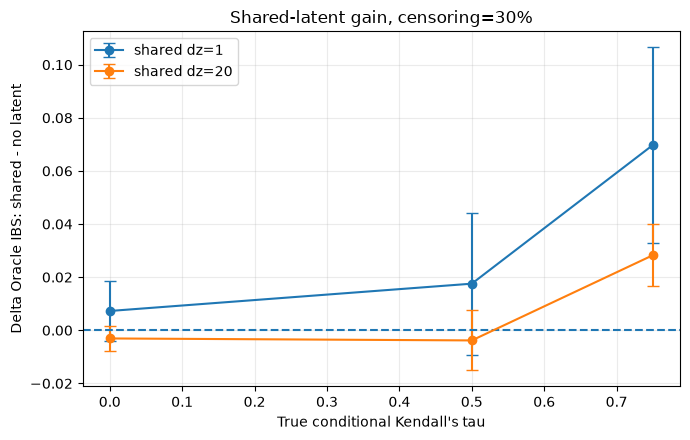

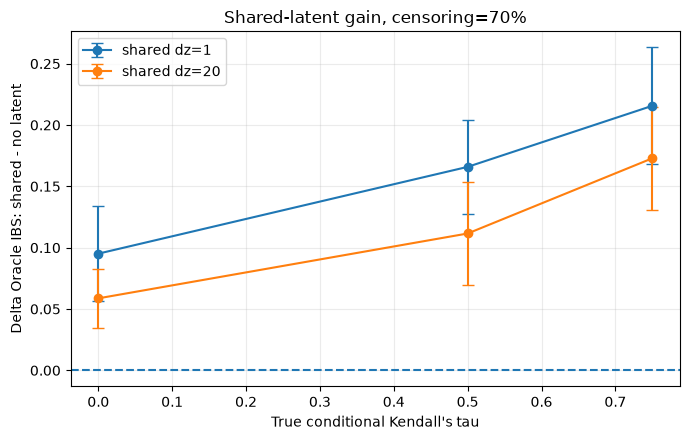

In [ ]:

for censoring in sorted(summary["target_censoring"].unique()):
    part = summary[summary["target_censoring"] == censoring]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for dz in sorted(part["latent_dim"].unique()):
        p = part[part["latent_dim"] == dz].sort_values("target_tau")
        ax.errorbar(
            p["target_tau"], p["mean_delta_ibs"],
            yerr=p["std_delta_ibs"],
            marker="o", capsize=4, label=f"shared dz={int(dz)}"
        )
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("True conditional Kendall's tau")
    ax.set_ylabel("Delta Oracle IBS: shared - no latent")
    ax.set_title(f"Shared-latent gain, censoring={censoring:.0%}")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


Desired pattern:
- near zero at \(\tau=0\);
- increasingly negative as dependence rises;
- larger gains under heavier censoring.


## 5. Does sharing the latent matter?

In [ ]:
control = (
    shared.dropna(subset=["separate_oracle_ibs"])
    .groupby(
        ["target_tau", "target_censoring", "latent_dim"], as_index=False
    )
    .agg(
        mean_delta=("delta_ibs_shared_vs_separate", "mean"),
        std_delta=("delta_ibs_shared_vs_separate", "std"),
        shared_win_rate=(
            "delta_ibs_shared_vs_separate",
            lambda x: np.mean(np.asarray(x) < 0),
        ),
    )
)
display(control)

,target_tau,target_censoring,latent_dim,mean_delta,std_delta,shared_win_rate
0,0.00,0.3,1,0.005154,0.010030,0.4
1,0.00,0.3,20,0.004266,0.004363,0.2
2,0.00,0.7,1,0.065186,0.049282,0.2
3,0.00,0.7,20,0.051664,0.023971,0.0
4,0.50,0.3,1,0.011894,0.024503,0.4
5,0.50,0.3,20,0.010089,0.008697,0.2
6,0.50,0.7,1,0.106713,0.071387,0.0
7,0.50,0.7,20,0.081733,0.053229,0.2
8,0.75,0.3,1,0.038076,0.041579,0.2
9,0.75,0.3,20,0.020478,0.010587,0.0


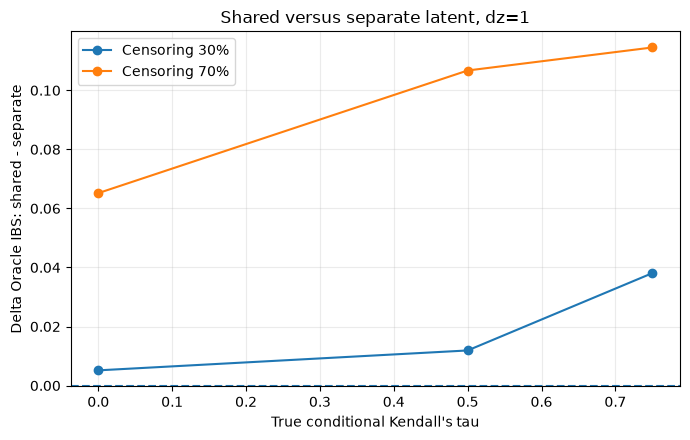

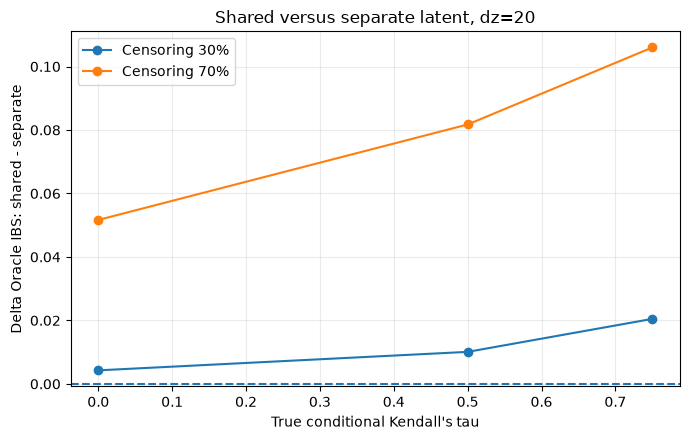

In [ ]:
for dz in sorted(control["latent_dim"].unique()):
    part = control[control["latent_dim"] == dz]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for censoring in sorted(part["target_censoring"].unique()):
        p = part[part["target_censoring"] == censoring].sort_values("target_tau")
        ax.plot(
            p["target_tau"], p["mean_delta"],
            marker="o", label=f"Censoring {censoring:.0%}"
        )
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("True conditional Kendall's tau")
    ax.set_ylabel("Delta Oracle IBS: shared - separate")
    ax.set_title(f"Shared versus separate latent, dz={int(dz)}")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 6. Learned dependence recovery

,target_tau,target_censoring,architecture,latent_dim,learned_tau,learned_tau_std
0,0.00,0.3,no_latent,0,-0.004012,0.023574
1,0.00,0.3,separate,1,-0.005782,0.015640
2,0.00,0.3,separate,20,0.000995,0.017314
3,0.00,0.3,shared,1,-0.343966,0.232184
4,0.00,0.3,shared,20,-0.127092,0.103800
5,0.00,0.7,no_latent,0,-0.004012,0.023574
6,0.00,0.7,separate,1,-0.005588,0.016754
7,0.00,0.7,separate,20,0.007536,0.024132
8,0.00,0.7,shared,1,-0.322587,0.113311
9,0.00,0.7,shared,20,-0.160095,0.076610


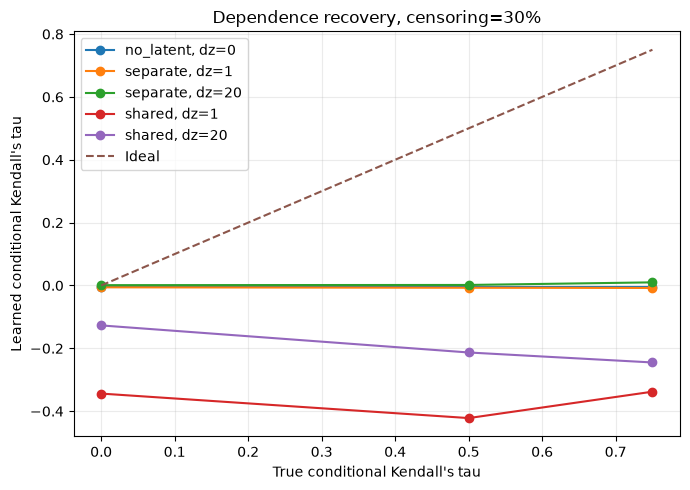

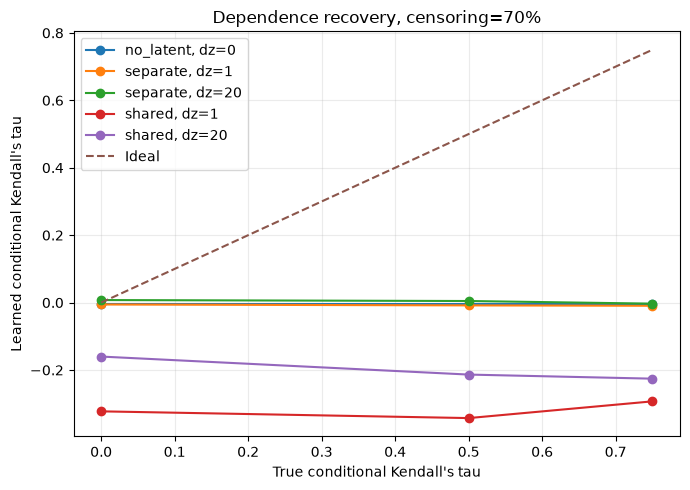

In [ ]:
if "learned_conditional_tau" in results.columns:
    tau_summary = (
        results.groupby(
            ["target_tau", "target_censoring", "architecture", "latent_dim"],
            as_index=False,
        )
        .agg(
            learned_tau=("learned_conditional_tau", "mean"),
            learned_tau_std=("learned_conditional_tau", "std"),
        )
    )
    display(tau_summary)

    for censoring in sorted(tau_summary["target_censoring"].unique()):
        part = tau_summary[tau_summary["target_censoring"] == censoring]
        fig, ax = plt.subplots(figsize=(7, 5))
        for (arch, dz), p in part.groupby(["architecture", "latent_dim"]):
            p = p.sort_values("target_tau")
            ax.plot(
                p["target_tau"], p["learned_tau"],
                marker="o", label=f"{arch}, dz={int(dz)}"
            )
        ax.plot([0, 0.75], [0, 0.75], linestyle="--", label="Ideal")
        ax.set_xlabel("True conditional Kendall's tau")
        ax.set_ylabel("Learned conditional Kendall's tau")
        ax.set_title(f"Dependence recovery, censoring={censoring:.0%}")
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()
else:
    print("No learned_conditional_tau column found.")

## 7. True frailty recovery

,target_tau,target_censoring,latent_dim,latent_r2,latent_r2_std,latent_pearson
0,0.00,0.3,1,-0.001529,0.001811,-0.016162
1,0.00,0.3,20,-0.010701,0.004878,-0.025373
2,0.00,0.7,1,-0.001518,0.001452,-0.018001
3,0.00,0.7,20,-0.012930,0.009153,-0.028948
4,0.50,0.3,1,0.032325,0.012532,0.185405
5,0.50,0.3,20,0.201437,0.232126,0.388728
6,0.50,0.7,1,0.039337,0.048603,0.182695
7,0.50,0.7,20,0.225240,0.265078,0.405983
8,0.75,0.3,1,0.029657,0.036117,0.139610
9,0.75,0.3,20,0.076496,0.039186,0.276247


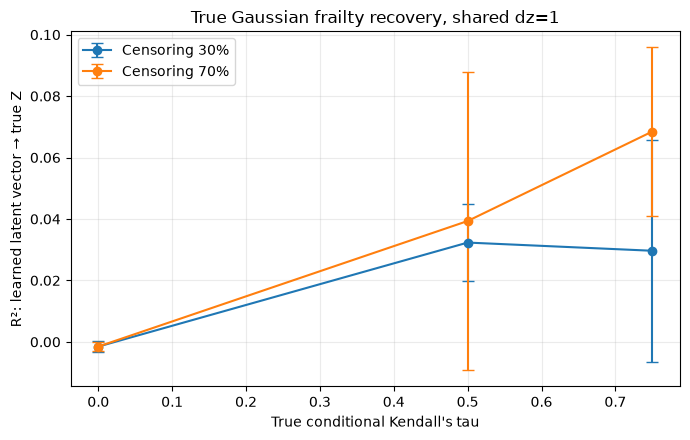

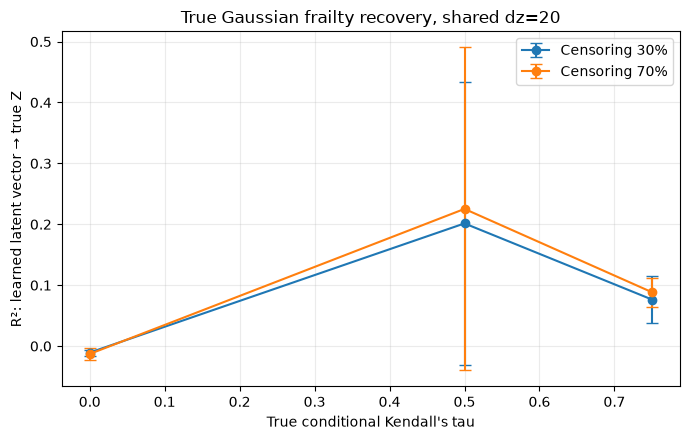

In [ ]:
shared_only = results[results["architecture"] == "shared"].copy()

if "latent_probe_r2" in shared_only.columns:
    latent = (
        shared_only.groupby(
            ["target_tau", "target_censoring", "latent_dim"], as_index=False
        )
        .agg(
            latent_r2=("latent_probe_r2", "mean"),
            latent_r2_std=("latent_probe_r2", "std"),
            latent_pearson=("latent_probe_pearson", "mean"),
        )
    )
    display(latent)

    for dz in sorted(latent["latent_dim"].unique()):
        part = latent[latent["latent_dim"] == dz]
        fig, ax = plt.subplots(figsize=(7, 4.5))
        for censoring in sorted(part["target_censoring"].unique()):
            p = part[part["target_censoring"] == censoring].sort_values("target_tau")
            ax.errorbar(
                p["target_tau"], p["latent_r2"],
                yerr=p["latent_r2_std"],
                marker="o", capsize=4,
                label=f"Censoring {censoring:.0%}"
            )
        ax.set_xlabel("True conditional Kendall's tau")
        ax.set_ylabel("R²: learned latent vector → true Z")
        ax.set_title(f"True Gaussian frailty recovery, shared dz={int(dz)}")
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()
else:
    print("No latent_probe_r2 column found.")

## 8. Effective latent dimensionality

,target_tau,target_censoring,latent_dim,active_dims,posterior_total_kl
0,0.00,0.3,1,1.0,1.260498
1,0.00,0.3,20,13.8,1.490023
2,0.00,0.7,1,1.0,0.998847
3,0.00,0.7,20,9.4,1.234212
4,0.50,0.3,1,1.0,1.174606
5,0.50,0.3,20,12.0,1.139348
6,0.50,0.7,1,1.0,1.055581
7,0.50,0.7,20,14.2,1.379429
8,0.75,0.3,1,1.0,1.137387
9,0.75,0.3,20,12.2,1.214423


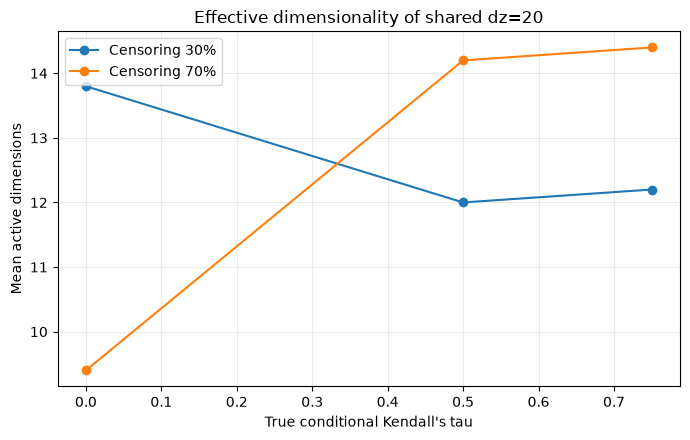

In [ ]:
if "active_dims" in shared_only.columns:
    active = (
        shared_only.groupby(
            ["target_tau", "target_censoring", "latent_dim"], as_index=False
        )
        .agg(
            active_dims=("active_dims", "mean"),
            posterior_total_kl=("posterior_total_kl", "mean"),
        )
    )
    display(active)

    dz20 = active[active["latent_dim"] == 20]
    if len(dz20):
        fig, ax = plt.subplots(figsize=(7, 4.5))
        for censoring in sorted(dz20["target_censoring"].unique()):
            p = dz20[dz20["target_censoring"] == censoring].sort_values("target_tau")
            ax.plot(
                p["target_tau"], p["active_dims"],
                marker="o", label=f"Censoring {censoring:.0%}"
            )
        ax.set_xlabel("True conditional Kendall's tau")
        ax.set_ylabel("Mean active dimensions")
        ax.set_title("Effective dimensionality of shared dz=20")
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()
else:
    print("No active_dims column found.")

## 9. Seed-level variability

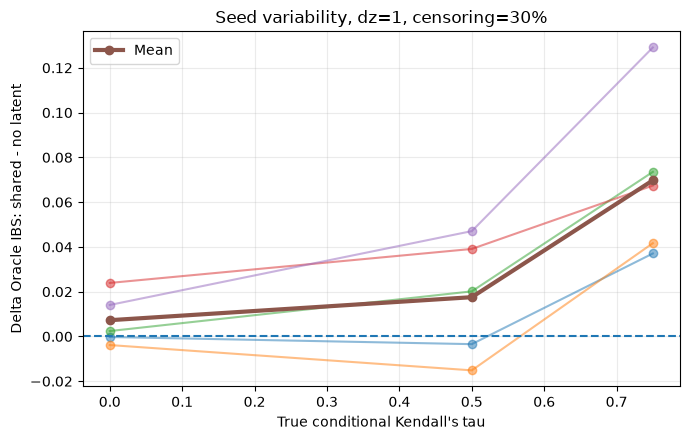

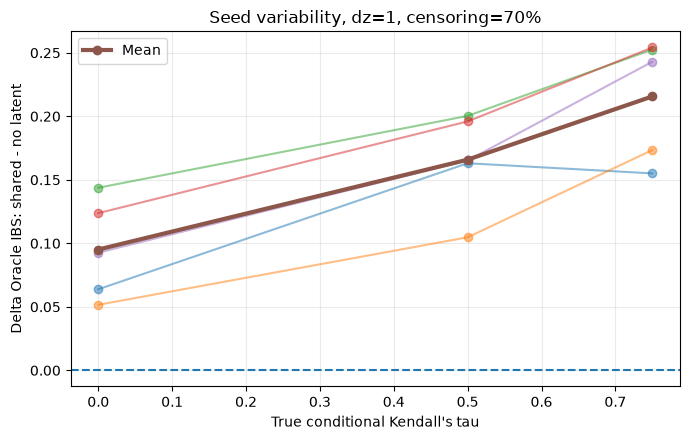

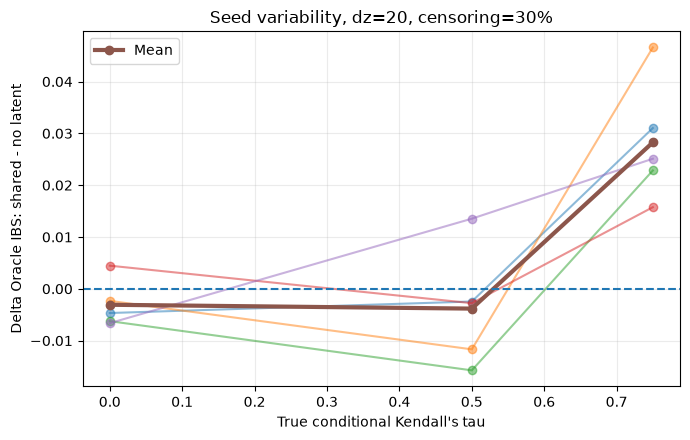

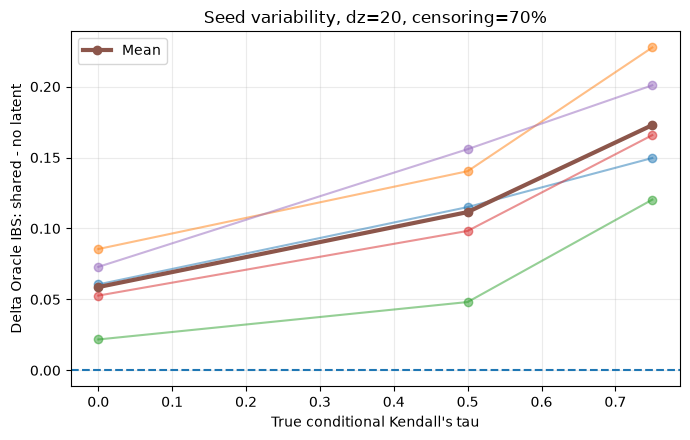

In [ ]:
for dz in sorted(shared["latent_dim"].unique()):
    for censoring in sorted(shared["target_censoring"].unique()):
        part = shared[
            (shared["latent_dim"] == dz)
            & (shared["target_censoring"] == censoring)
        ]
        fig, ax = plt.subplots(figsize=(7, 4.5))
        for seed, p in part.groupby("seed"):
            p = p.sort_values("target_tau")
            ax.plot(
                p["target_tau"], p["delta_ibs_vs_no_latent"],
                marker="o", alpha=0.5
            )
        mean_p = (
            part.groupby("target_tau", as_index=False)["delta_ibs_vs_no_latent"]
            .mean()
            .sort_values("target_tau")
        )
        ax.plot(
            mean_p["target_tau"], mean_p["delta_ibs_vs_no_latent"],
            marker="o", linewidth=3, label="Mean"
        )
        ax.axhline(0, linestyle="--")
        ax.set_xlabel("True conditional Kendall's tau")
        ax.set_ylabel("Delta Oracle IBS: shared - no latent")
        ax.set_title(
            f"Seed variability, dz={int(dz)}, censoring={censoring:.0%}"
        )
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

## 10. Compact decision table

In [ ]:
decision = summary.merge(
    control[
        ["target_tau", "target_censoring", "latent_dim",
         "mean_delta", "shared_win_rate"]
    ].rename(columns={
        "mean_delta": "delta_ibs_shared_vs_separate",
        "shared_win_rate": "shared_vs_separate_win_rate",
    }),
    on=["target_tau", "target_censoring", "latent_dim"],
    how="left",
)

if "learned_conditional_tau" in shared_only.columns:
    t = (
        shared_only.groupby(
            ["target_tau", "target_censoring", "latent_dim"], as_index=False
        )
        .agg(
            learned_tau=("learned_conditional_tau", "mean"),
            tau_error=("tau_absolute_error", "mean"),
        )
    )
    decision = decision.merge(
        t,
        on=["target_tau", "target_censoring", "latent_dim"],
        how="left",
    )

if "latent_probe_r2" in shared_only.columns:
    z = (
        shared_only.groupby(
            ["target_tau", "target_censoring", "latent_dim"], as_index=False
        )
        .agg(latent_r2=("latent_probe_r2", "mean"))
    )
    decision = decision.merge(
        z,
        on=["target_tau", "target_censoring", "latent_dim"],
        how="left",
    )

display(decision.sort_values(
    ["latent_dim", "target_censoring", "target_tau"]
))

,target_tau,target_censoring,latent_dim,mean_delta_ibs,std_delta_ibs,mean_shared_ibs,mean_no_latent_ibs,win_rate,n_seeds,delta_ibs_shared_vs_separate,shared_vs_separate_win_rate,learned_tau,tau_error,latent_r2
0,0.00,0.3,1,0.007268,0.011475,0.143459,0.136191,0.4,5,0.005154,0.4,-0.343966,0.346370,-0.001529
4,0.50,0.3,1,0.017549,0.026695,0.179486,0.161936,0.4,5,0.011894,0.4,-0.421920,0.921920,0.032325
8,0.75,0.3,1,0.069753,0.036734,0.202192,0.132439,0.0,5,0.038076,0.2,-0.337944,1.087944,0.029657
2,0.00,0.7,1,0.095122,0.038929,0.233552,0.138430,0.0,5,0.065186,0.2,-0.322587,0.322587,-0.001518
6,0.50,0.7,1,0.165863,0.038205,0.368084,0.202221,0.0,5,0.106713,0.0,-0.342571,0.842571,0.039337
10,0.75,0.7,1,0.215633,0.047550,0.433499,0.217865,0.0,5,0.114512,0.0,-0.292960,1.042960,0.068462
1,0.00,0.3,20,-0.003079,0.004545,0.133112,0.136191,0.8,5,0.004266,0.2,-0.127092,0.127092,-0.010701
5,0.50,0.3,20,-0.003821,0.011270,0.158115,0.161936,0.8,5,0.010089,0.2,-0.213197,0.713197,0.201437
9,0.75,0.3,20,0.028264,0.011608,0.160702,0.132439,0.0,5,0.020478,0.0,-0.244975,0.994975,0.076496
3,0.00,0.7,20,0.058696,0.024109,0.197126,0.138430,0.0,5,0.051664,0.0,-0.160095,0.160095,-0.012930



## 11. How to decide the next direction

**Move to the 10-dataset semi-synthetic benchmark** if:
- shared beats no-latent under dependence;
- the gain is small/absent at \(\tau=0\);
- shared beats separate;
- learned dependence tracks true dependence;
- true frailty is recoverable.

**Do more targeted synthetic diagnostics** if:
- only \(d_z=20\) works while \(d_z=1\) fails despite a scalar true frailty;
- prediction improves but dependence recovery is weak.

**Refactor the model/objective before scaling up** if:
- shared fails even in this matched Gaussian/Weibull setting;
- shared and separate perform similarly;
- learned dependence is poor under strong true dependence.


## 12. Optional training-history inspection

Training history files: 150
Example: seed0_tau0p00_cens0p30_no_latent_dz0.csv


,epoch,beta,train_loss,train_reconstruction_nll,train_kl,validation_loss,validation_reconstruction_nll,validation_kl,learning_rate
0,1,0.0,0.065318,0.065318,0.0,-0.053321,-0.053321,0.0,0.001
1,2,0.0,-0.097273,-0.097273,0.0,-0.164247,-0.164247,0.0,0.001
2,3,0.0,-0.201264,-0.201264,0.0,-0.241895,-0.241895,0.0,0.001
3,4,0.0,-0.271766,-0.271766,0.0,-0.294925,-0.294925,0.0,0.001
4,5,0.0,-0.318769,-0.318769,0.0,-0.307191,-0.307191,0.0,0.001


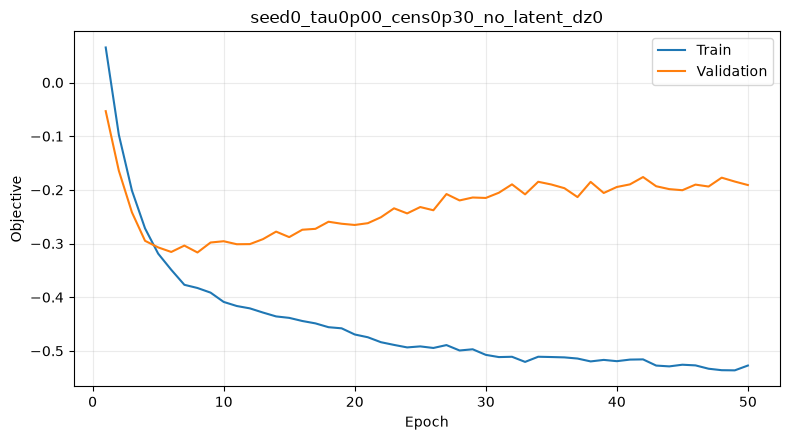

In [ ]:
history_files = sorted(HISTORY_DIR.glob("*.csv")) if HISTORY_DIR.exists() else []
print("Training history files:", len(history_files))

if history_files:
    path = history_files[0]
    hist = pd.read_csv(path)
    print("Example:", path.name)
    display(hist.head())

    if {"epoch", "train_loss", "validation_loss"}.issubset(hist.columns):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.plot(hist["epoch"], hist["train_loss"], label="Train")
        ax.plot(hist["epoch"], hist["validation_loss"], label="Validation")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Objective")
        ax.set_title(path.stem)
        ax.legend()
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()